# Bitcoin News Sentiment Analysis (2021-2024)

## Overview
This project analyses 11,295 Bitcoin news headlines to classify
public sentiment as Positive, Negative or Neutral using Python
NLP techniques. It uncovers how media coverage of Bitcoin shifted
during market crashes, recoveries and major financial events.

- **Dataset:** Bitcoin Sentiments 2021-2024 — Kaggle
- **Tools:** Python, Pandas, Matplotlib, Seaborn
- **Author:** HT Olugbade

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('bitcoin_sentiments_21_24.csv')

# Check shape
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

# Check exact column names
for col in df.columns:
    print(col)

Rows: 11295 | Columns: 3
Date
Short Description
Accurate Sentiments


In [2]:
# Preview first 5 rows
print(df.head())

# Check sentiment categories
print("\nSentiment Values:")
print(df['Accurate Sentiments'].value_counts())

                  Date                                  Short Description  \
0  2021-11-05 04:42:00  Bitcoin price is consolidating near the USD 62...   
1  2021-11-05 08:15:00  Congress could finally approve or reject the m...   
2  2021-11-05 10:24:00  Bitcoin increasingly becoming a political inst...   
3  2021-11-05 16:58:00  There is still potential for the price of bitc...   
4  2021-11-05 21:00:00  'Several companies' are looking to Latin Ameri...   

   Accurate Sentiments  
0             0.998558  
1             0.000000  
2             0.000000  
3             0.999458  
4             0.000000  

Sentiment Values:
Accurate Sentiments
 0.000000    4445
 0.999587       5
 0.999588       5
 0.999647       5
 0.999620       4
             ... 
 0.979985       1
 0.999689       1
 0.999714       1
-0.989155       1
 0.997017       1
Name: count, Length: 6188, dtype: int64


In [3]:
# Convert sentiment scores into categories
def classify_sentiment(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'
    
df['Sentiment'] = df['Accurate Sentiments'].apply(classify_sentiment)

# Also convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

# Check results
print(df['Sentiment'].value_counts())

Sentiment
Neutral     4445
Positive    3949
Negative    2901
Name: count, dtype: int64


In [4]:
# Import visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries ready!")

Libraries ready!


### 1. Overall Sentiment Distribution
What is the general tone of Bitcoin news coverage?

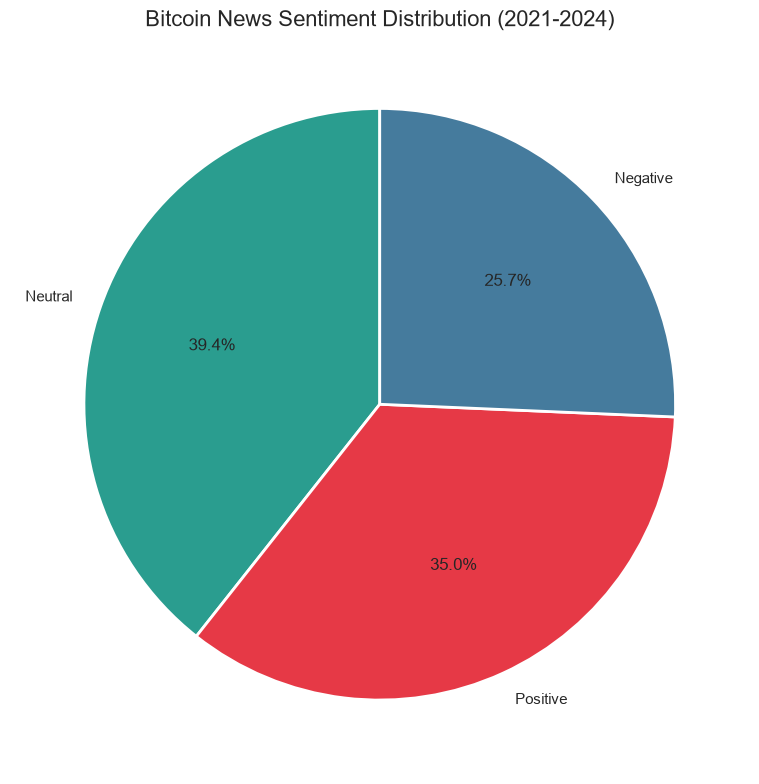

In [5]:
# Chart 1 - Overall Sentiment Distribution
sentiment_counts = df['Sentiment'].value_counts()

colors = ['#2a9d8f', '#e63946', '#457b9d']

plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts.values,
        labels=sentiment_counts.index,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Bitcoin News Sentiment Distribution (2021-2024)',
          fontsize=16)
plt.tight_layout()
plt.show()

**Finding:** Bitcoin news is predominantly Neutral (39.4%),
followed by Positive (35%) and Negative (25.7%). Despite
Bitcoin's volatile reputation, media coverage leans
more positive than negative overall.

### 2. Sentiment by Year
How did Bitcoin news sentiment change year by year?

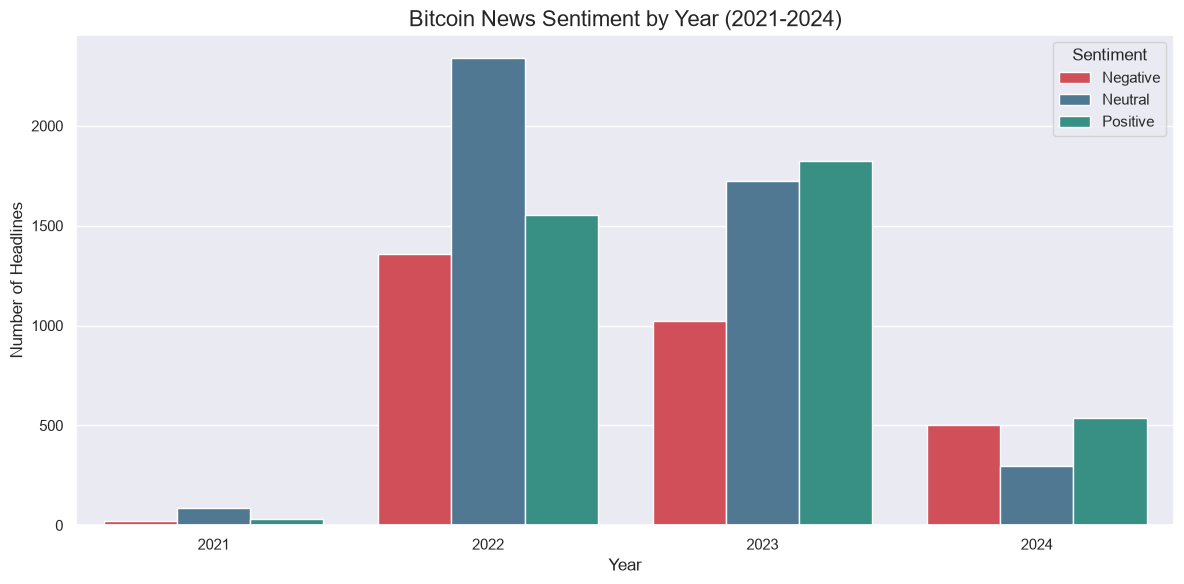

In [6]:
# Chart 2 - Sentiment Count by Year
yearly_sentiment = df.groupby(['Year', 'Sentiment']).size().reset_index(name='Count')

plt.figure(figsize=(12, 6))
sns.barplot(data=yearly_sentiment,
            x='Year',
            y='Count',
            hue='Sentiment',
            palette=['#e63946', '#457b9d', '#2a9d8f'])
plt.title('Bitcoin News Sentiment by Year (2021-2024)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Headlines', fontsize=12)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

**Finding:** 2022 saw the highest volume of headlines across
all sentiments - coinciding with Bitcoin's historic crash
from $69K to $16K. Coverage dropped significantly by 2024
as market volatility reduced.

### 3. Negative Sentiment Trend
When was Bitcoin covered most negatively?

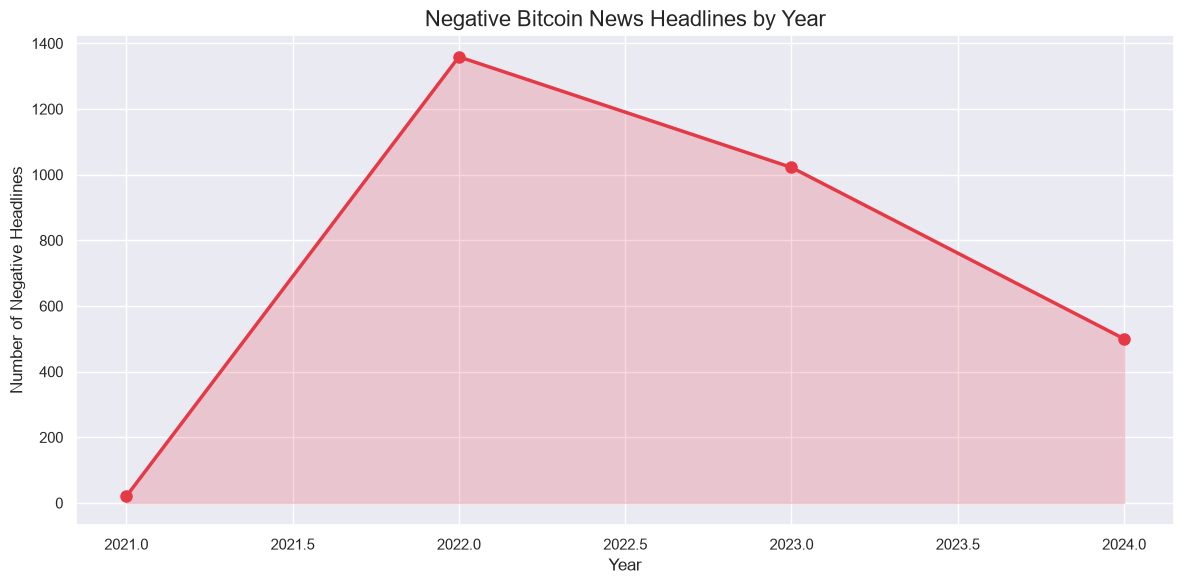

In [7]:
# Chart 3 - Negative Sentiment Trend by Year
negative_by_year = df[df['Sentiment'] == 'Negative'].groupby('Year').size()

plt.figure(figsize=(12, 6))
plt.plot(negative_by_year.index,
         negative_by_year.values,
         marker='o',
         color='#e63946',
         linewidth=2.5,
         markersize=8)
plt.fill_between(negative_by_year.index,
                 negative_by_year.values,
                 alpha=0.2,
                 color='#e63946')
plt.title('Negative Bitcoin News Headlines by Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Negative Headlines', fontsize=12)
plt.tight_layout()
plt.show()

**Finding:** Negative headlines peaked sharply in 2022
during the crypto winter. Since then negative coverage
has steadily declined - reflecting growing market
confidence and Bitcoin's price recovery.

### 4. Most Common Words in Headlines
What topics dominate Bitcoin news coverage?

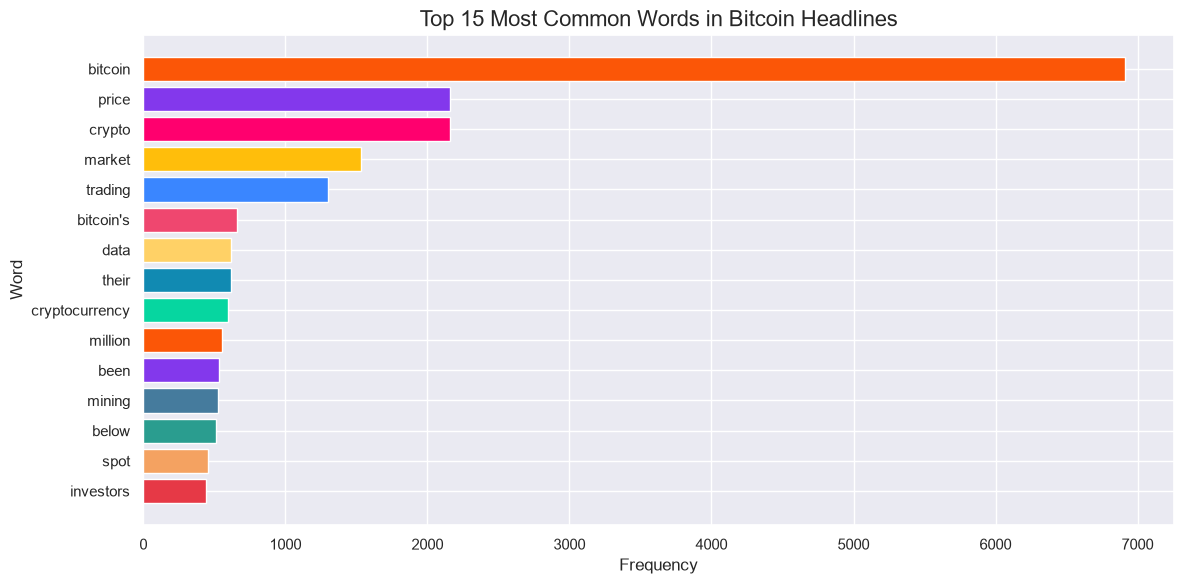

In [8]:
# Chart 4 - Most Common Words in Headlines
from collections import Counter

# Combine all headlines into one text
all_words = ' '.join(df['Short Description'].dropna()).lower().split()

# Remove common unimportant words
stopwords = ['the', 'a', 'an', 'is', 'in', 'of', 'to', 'and',
             'for', 'on', 'that', 'with', 'as', 'it', 'are',
             'was', 'be', 'by', 'its', 'at', 'has', 'have',
             'from', 'this', 'will', 'not', 'or', 'but', 'he',
             'she', 'they', 'his', 'her', 'how', 'what', 'than',
             'could', 'would', 'more', 'over', 'after', 'about']

filtered_words = [w for w in all_words if w not in stopwords and len(w) > 3]

# Count top 15 words
word_counts = Counter(filtered_words).most_common(15)
words = [w[0] for w in word_counts]
counts = [w[1] for w in word_counts]

colors = ['#e63946','#f4a261','#2a9d8f','#457b9d','#8338ec',
          '#fb5607','#06d6a0','#118ab2','#ffd166','#ef476f',
          '#3a86ff','#ffbe0b','#ff006e','#8338ec','#fb5607']

plt.figure(figsize=(12, 6))
plt.barh(words[::-1], counts[::-1], color=colors)
plt.title('Top 15 Most Common Words in Bitcoin Headlines', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.tight_layout()
plt.show()

**Finding:** Price, market and trading dominate Bitcoin
headlines - confirming that media coverage is driven
by financial performance rather than technology
or innovation.

### 5. Positive vs Negative Headlines by Year
Did positive or negative coverage dominate each year?

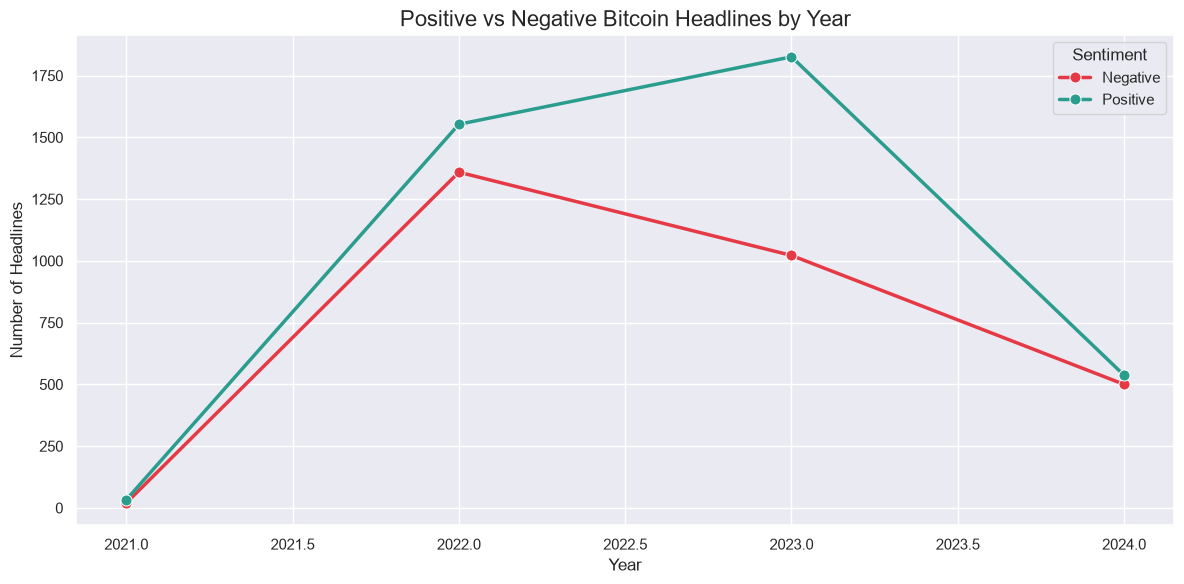

In [9]:
# Chart 5 - Positive vs Negative Ratio by Year
pos_neg = df[df['Sentiment'].isin(['Positive', 'Negative'])]
pos_neg_year = pos_neg.groupby(['Year', 'Sentiment']).size().reset_index(name='Count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=pos_neg_year,
             x='Year',
             y='Count',
             hue='Sentiment',
             palette=['#e63946', '#2a9d8f'],
             marker='o',
             linewidth=2.5,
             markersize=8)
plt.title('Positive vs Negative Bitcoin Headlines by Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Headlines', fontsize=12)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

Finding: Positive headlines consistently outweighed
negative ones every single year - even during the 2022
crash. This suggests media sentiment is a leading
indicator of market recovery, not just a reaction to it.

## Key Findings

- **Media tone is mostly neutral** - facts over fear
- **2022 was the crisis year** - peak negative coverage
- **Positive always won** - even during the worst crash
- **Price drives everything** - most common word after Bitcoin
- **Sentiment is recovering** - negative coverage falling since 2022

## Conclusion
Bitcoin media sentiment directly mirrors market cycles.
The data shows that even during crypto's worst year,
positive coverage dominated - suggesting media sentiment
may be a powerful early indicator of market recovery.